# Master table quick exploration

Lightweight exploratory notebook for the NOGSE pipeline master table.

Main use cases:

- Inspect selected columns with pandas.
- Plot OGSE signal versus `g_thorsten`.
- Plot contrast versus `g_thorsten`.
- Compare all contrasts across `td_ms`, with `long` and `tra` directions side by side.

The notebook intentionally keeps the logic simple and local so that new analysis blocks can be appended incrementally.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

## 1. Load the master table

Adjust `MASTER_PATH` if your table lives elsewhere. Prefer parquet for speed; xlsx is supported for quick manual exports.

In [3]:
MASTER_PATH = Path("../../analysis/brains/ogse_experiments/master.long.parquet")

print("Current directory:", Path.cwd())
print("Master path:", MASTER_PATH.resolve())
print("Exists:", MASTER_PATH.exists())

Current directory: /mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure/nogse_pipeline/notebooks
Master path: /mnt/storage/tier2/MUMI-EXT-001/mumi-data/Project-Balseiro-Microstructure/analysis/brains/ogse_experiments/master.long.parquet
Exists: True


In [4]:
df = pd.read_parquet(MASTER_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

df.head()

Rows: 183,920
Columns: 46


,row_kind,analysis_id,subj,sheet,roi,direction,stat,b_step,value,value_norm,D_proj,grad_correction_factor,alpha_macro,td_ms,N,Hz,source_file,source_path,source_hash,bvalue,bvalue_orig,bvalue_g,bvalue_g_lin_max,bvalue_thorsten,bmax,g,g_max,g_lin_max,g_thorsten,gradient_axis_kind,one_g_per_sequence,S0,TE,TR,max_dur_ms,Delta_app_ms,delta_ms,tm_ms,TN,G,x,y,type,sequence,group,protocol
0,signal,signal_subj-BRAIN_sheet-20220622_BRAIN_type-PG...,BRAIN,20220622_BRAIN,AntCC,1,avg,0,250.646158,1.000000,NaN,NaN,NaN,90.0,1,0.0,20220622_BRAIN_ep2d_advdiff_AP_919D_OGSE_10bva...,None,None,0.0,0.0,0.0,0.0,0.000000,2000.0,0.000000,21.382748,0.000000,0.000000,b,False,250.646158,117.0,6000.0,40.0,38.2,40.0,10.0,NaN,NaN,NaN,NaN,PGSE monopolar,5.0,None,20220617_GONZANY_ADVDIFF
1,signal,signal_subj-BRAIN_sheet-20220622_BRAIN_type-PG...,BRAIN,20220622_BRAIN,AntCC,1,avg,1,227.086068,0.906003,0.004936,NaN,NaN,90.0,1,0.0,20220622_BRAIN_ep2d_advdiff_AP_919D_OGSE_10bva...,None,None,20.0,20.0,20.0,20.0,19.947426,2000.0,2.138275,21.382748,2.138275,2.135462,b,False,250.646158,117.0,6000.0,40.0,38.2,40.0,10.0,NaN,NaN,NaN,NaN,PGSE monopolar,5.0,None,20220617_GONZANY_ADVDIFF
2,signal,signal_subj-BRAIN_sheet-20220622_BRAIN_type-PG...,BRAIN,20220622_BRAIN,AntCC,1,avg,2,195.928817,0.781695,0.003079,NaN,NaN,90.0,1,0.0,20220622_BRAIN_ep2d_advdiff_AP_919D_OGSE_10bva...,None,None,80.0,80.0,80.0,80.0,79.789703,2000.0,4.276550,21.382748,4.276550,4.270925,b,False,250.646158,117.0,6000.0,40.0,38.2,40.0,10.0,NaN,NaN,NaN,NaN,PGSE monopolar,5.0,None,20220617_GONZANY_ADVDIFF
3,signal,signal_subj-BRAIN_sheet-20220622_BRAIN_type-PG...,BRAIN,20220622_BRAIN,AntCC,1,avg,3,166.929024,0.665995,0.002258,NaN,NaN,90.0,1,0.0,20220622_BRAIN_ep2d_advdiff_AP_919D_OGSE_10bva...,None,None,180.0,180.0,180.0,180.0,179.526832,2000.0,6.414824,21.382748,6.414824,6.406387,b,False,250.646158,117.0,6000.0,40.0,38.2,40.0,10.0,NaN,NaN,NaN,NaN,PGSE monopolar,5.0,None,20220617_GONZANY_ADVDIFF
4,signal,signal_subj-BRAIN_sheet-20220622_BRAIN_type-PG...,BRAIN,20220622_BRAIN,AntCC,1,avg,4,137.190440,0.547347,0.001883,NaN,NaN,90.0,1,0.0,20220622_BRAIN_ep2d_advdiff_AP_919D_OGSE_10bva...,None,None,320.0,320.0,320.0,320.0,319.158812,2000.0,8.553099,21.382748,8.553099,8.541850,b,False,250.646158,117.0,6000.0,40.0,38.2,40.0,10.0,NaN,NaN,NaN,NaN,PGSE monopolar,5.0,None,20220617_GONZANY_ADVDIFF


## 2. Quick inventory

In [5]:
def show_unique_values(df: pd.DataFrame, columns: list[str], max_values: int = 100) -> None:
    """Print compact unique-value summaries for selected columns."""
    for col in columns:
        if col not in df.columns:
            print(f"\n{col}: <missing>")
            continue

        values = df[col].dropna().unique()
        values = sorted(values, key=lambda x: str(x))
        preview = values[:max_values]
        print(f"\n{col} ({len(values)} unique):")
        print(preview)


show_unique_values(
    df,
    [
        "row_kind",
        "subj",
        "sheet",
        "roi",
        "direction",
        "stat",
        "N",
        # "N_1",
        # "N_2",
        "td_ms",
        # "Hz",
        # "Hz_1",
        # "Hz_2",
        "type",
    ],
)


row_kind (2 unique):
['signal', 'signal_rotated']

subj (3 unique):
['BRAIN', 'LUDG', 'MBBL']

sheet (7 unique):
['20220622_BRAIN', '20230619_BRAIN-3', '20230623_BRAIN-4', '20230623_LUDG-2', '20230629_MBBL-2', '20230630_MBBL-3', '20230710_LUDG-3']

roi (8 unique):
['AntCC', 'CentralCC', 'Left-Lateral-Ventricle', 'MidAntCC', 'MidPostCC', 'PostCC', 'Right-Lateral-Ventricle', 'Syringe']

direction (14 unique):
['1', '2', '3', '4', '5', '6', 'eig1', 'eig2', 'eig3', 'long', 'tra', 'x', 'y', 'z']

stat (5 unique):
['avg', 'mad', 'med', 'mode', 'std']

N (8 unique):
[np.int64(1), np.int64(12), np.int64(16), np.int64(20), np.int64(24), np.int64(28), np.int64(4), np.int64(8)]

td_ms (5 unique):
[np.float64(120.0), np.float64(143.4), np.float64(210.0), np.float64(76.0), np.float64(90.0)]

type (2 unique):
['OGSE (cos)', 'PGSE monopolar']


## 3. Small filtering helpers

In [6]:
def select_rows(df, row_kind, subj, roi, direction, stat="avg", N=None, td_ms=None, D_proj=None):
    """Select rows from the master table using the main filters."""
    return df[
        (df["row_kind"] == row_kind) &
        (df["subj"] == subj) &
        (df["roi"] == roi) &
        (df["direction"] == str(direction)) &
        (df["stat"] == stat) &
        (df["N"] == N) &
        (df["td_ms"] == td_ms)
    ].copy()

## 4. Quick pandas table selection

Edit the variables below to inspect a specific ROI/subject/direction.

In [7]:
df = pd.read_parquet(MASTER_PATH)
MASTER_PATH = Path("../../analysis/brains/ogse_experiments/master.long.parquet")

subj = "MBBL"
roi = "AntCC"  # Example ROI; change as needed
td_ms =  210.0# Example td_ms; change as needed
dir = "long"
signal = select_rows(
    df,
    row_kind="signal_rotated", #signal, signal_rotated, dproj
    subj=subj,
    roi=roi,
    N=4,
    td_ms=td_ms,
    direction=dir,
    stat="avg",
    # D_proj="D_proj"
)

signal1 = select_rows(
    df,
    row_kind="signal_rotated", #signal, signal_rotated, dproj
    subj=subj,
    roi=roi,
    N=8,
    td_ms=td_ms,
    direction=dir,
    stat="avg",
    # D_proj="D_proj"
)

print("ROI:", roi)
n4 = 3
n8 = 3

mean_n4 = signal["value"].tail(n4).mean()
mean_n8 = signal1["value"].tail(n8).mean()

sem_n4 = signal["value"].tail(n4).std() / np.sqrt(n4)
sem_n8 = signal1["value"].tail(n8).std() / np.sqrt(n8)

mean_difference = mean_n4 - mean_n8
combined_sem = np.sqrt(sem_n4**2 + sem_n8**2)
standardized_difference = mean_difference / combined_sem

print(subj)
print(td_ms)
print("Tail N=4:", mean_n4, "+-", sem_n4)
print("Tail N=8:", mean_n8, "+-", sem_n8)
print("Absolute difference:", mean_difference)
print("Combined SEM:", combined_sem)
print("Standardized difference:", standardized_difference)

print("\nFull data for N=4 and N=8:")
print("N=4")
print(signal[["row_kind", "subj", "roi", "value", "value_norm", "g_thorsten", "D_proj", "N", "td_ms", "Hz", "b_step"]])
print("--------------------------------------------------")
print("N=8")
print(signal1[["row_kind", "subj", "roi", "value", "value_norm", "g_thorsten", "D_proj", "N", "td_ms", "Hz", "b_step"]])

ROI: AntCC
MBBL
210.0
Tail N=4: 35.18685651259876 +- 0.48218397001699315
Tail N=8: 35.82558749294819 +- 0.5997618758656035
Absolute difference: -0.638730980349429
Combined SEM: 0.7695555137111136
Standardized difference: -0.8299998752126473

Full data for N=4 and N=8:
N=4
              row_kind  subj    roi       value  value_norm  g_thorsten    D_proj  N  td_ms    Hz  b_step
176605  signal_rotated  MBBL  AntCC  111.555940    1.000000    0.000000       NaN  4  210.0  10.0       0
176606  signal_rotated  MBBL  AntCC   90.842409    0.814322    5.190164  0.002563  4  210.0  10.0       1
176607  signal_rotated  MBBL  AntCC   65.165405    0.584150   10.380328  0.001677  4  210.0  10.0       2
176608  signal_rotated  MBBL  AntCC   43.235304    0.387566   15.570491  0.001314  4  210.0  10.0       3
176609  signal_rotated  MBBL  AntCC   35.061795    0.314298   20.760655  0.000903  4  210.0  10.0       4
176610  signal_rotated  MBBL  AntCC   37.240272    0.333826   25.950819  0.000548  4  210.0

## 5. Plot OGSE signal versus `g_thorsten`

This is intended for one signal curve, selected by subject, ROI, direction, `N`, and optionally `td_ms` or `Hz`.

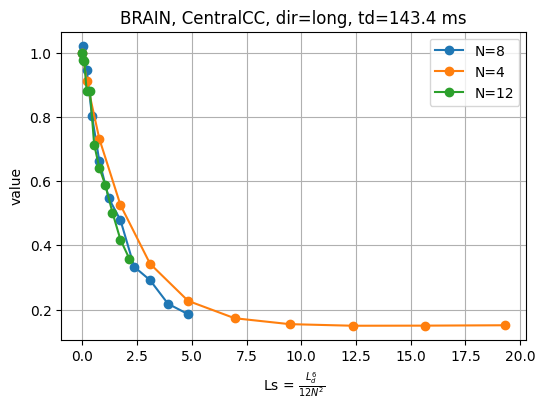

In [14]:
# Parameters
subj = "BRAIN"
roi = "CentralCC"
direction = "long"
stat = "avg"
N1 = 8
N2 = 4
N3 = 12
td_ms = 143.4

gamma = 267.5221900   # rad / (ms · mT), proton gyromagnetic ratio
D0    = 3.2e-12 

# Select one signal curve
signal1 = df[
    (df["row_kind"] == "signal_rotated") &
    (df["subj"] == subj) &
    (df["roi"] == roi) &
    (df["direction"].astype(str) == str(direction)) &
    (df["stat"] == stat) &
    (df["N"] == N1) &
    (np.isclose(pd.to_numeric(df["td_ms"], errors="coerce"), td_ms))
].copy()

signal2 = df[
    (df["row_kind"] == "signal_rotated") &
    (df["subj"] == subj) &
    (df["roi"] == roi) &
    (df["direction"].astype(str) == str(direction)) &
    (df["stat"] == stat) &
    (df["N"] == N2) &
    (np.isclose(pd.to_numeric(df["td_ms"], errors="coerce"), td_ms))
].copy()

signal3 = df[
    (df["row_kind"] == "signal_rotated") &
    (df["subj"] == subj) &
    (df["roi"] == roi) &
    (df["direction"].astype(str) == str(direction)) &
    (df["stat"] == stat) &
    (df["N"] == N3) &
    (np.isclose(pd.to_numeric(df["td_ms"], errors="coerce"), td_ms))
].copy()

signal1 = signal1.dropna(subset=["g_thorsten", "value_norm"])
signal2 = signal2.dropna(subset=["g_thorsten", "value_norm"])
signal3 = signal3.dropna(subset=["g_thorsten", "value_norm"])
# contrast = signal1["value_norm"].values - signal2["value_norm"].values

l_d = np.sqrt(D0 * float(td_ms))

l_G_1 = (D0 / (gamma * signal1["g_thorsten"])) ** (1.0 / 3.0)
Ld_1  = l_d / l_G_1

l_G_2 = (D0 / (gamma * signal2["g_thorsten"])) ** (1.0 / 3.0)
Ld_2  = l_d / l_G_2

l_G_3 = (D0 / (gamma * signal3["g_thorsten"])) ** (1.0 / 3.0)
Ld_3  = l_d / l_G_3

plt.figure(figsize=(6, 4))

plt.plot((Ld_1**6)/(12*N1**2), signal1["value_norm"], "o-", label=f"N={N1}")
plt.plot((Ld_1**6)/(12*N2**2), signal2["value_norm"], "o-", label=f"N={N2}")
plt.plot((Ld_1**6)/(12*N3**2), signal3["value_norm"], "o-", label=f"N={N3}")

# plt.plot(signal1["g_thorsten"], signal1["value_norm"], "o-", label=f"N={N1}")
# plt.plot(signal2["g_thorsten"], signal2["value_norm"], "o-", label=f"N={N2}")
# plt.plot(signal1["g_thorsten"], contrast, "o-", label="contrast")
plt.title(f"{subj}, {roi}, dir={direction}, td={td_ms:.1f} ms")
plt.xlabel(r"Ls = $\frac{L_d^6}{12 N^2}$")
plt.ylabel("value")
#plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()




## 6. Plot contrast versus `g_thorsten`

This assumes contrast rows are stored in the master table with `row_kind == "contrast"`.

## 7. All contrast curves across `td_ms`: long left, tra right

In [9]:
# Parameters
subj = "BRAIN"
roi = "AntCC"
direction = "1"
stat = "avg"
N1 = 8
N2 = 4
td_ms = 90.0

# Select one contrast curve
contrast = df[
    (df["row_kind"] == "contrast") &
    (df["subj"] == subj) &
    (df["roi"] == roi) &
    (df["direction"].astype(str) == str(direction)) &
    (df["stat"] == stat) &
    (df["N_1"] == N1) &
    (df["N_2"] == N2) &
    (np.isclose(pd.to_numeric(df["td_ms"], errors="coerce"), td_ms))
].copy()

contrast = contrast.dropna(subset=["g_thorsten", "value_norm"])
contrast = contrast.sort_values("g_thorsten")

print("Rows:", len(contrast))

plt.figure(figsize=(6, 4))
plt.plot(contrast["g_thorsten"], contrast["value_norm"], "o-", label=f"N={N1} - N={N2}")
plt.title(f"{subj}, {roi}, dir={direction}, td={td_ms:.1f} ms")
plt.xlabel("g_thorsten [mT/m]")
plt.ylabel("contrast value_norm")
plt.legend()
plt.grid(True)
plt.show()

contrast[["g_thorsten", "value_norm", "b_step", "td_ms", "N_1", "N_2", "source_file"]]

KeyError: 'N_1'

## 8. Small reusable snippets

Copy and adapt these cells when adding new quick analyses.

In [ ]:
# Example: inspect only two columns for one ROI/subject/direction.
quick_table = select_table(
    df,
    row_kind="signal",
    subj="BRAIN",
    roi="AntCC",
    direction="1",
    stat="avg",
    columns=["value_norm", "g_thorsten"],
)

quick_table.head(20)

In [ ]:
# Example: get all available td_ms values for a specific contrast selection.
td_available = (
    select_table(
        df,
        row_kind="contrast",
        subj="BRAIN",
        roi="AntCC",
        direction="long",
        stat="avg",
        columns=["td_ms"],
        N_1=8,
        N_2=4,
    )["td_ms"]
    .dropna()
    .sort_values()
    .unique()
)

td_available